# **1. Exploring the GPT-2 (124M) OpenAI checkpoint**

In [13]:
from transformers import GPT2LMHeadModel
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import functional as F
from dataclasses import dataclass
import tiktoken
import os
import json
import requests
from tqdm import tqdm
%matplotlib inline

In [14]:
model_hf = GPT2LMHeadModel.from_pretrained('gpt2') # 124M
sd_hf = model_hf.state_dict() # raw tensors

for k, v in sd_hf.items():
  print(k, v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [15]:
x = torch.tensor([[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13, 198]])
model_hf(x).logits.shape

torch.Size([1, 25, 50257])

In [ ]:
sd_hf['transformer.wpe.weight'].view(-1)[:20] # wpe: weights of positional embedding (block_size, n_embd)

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

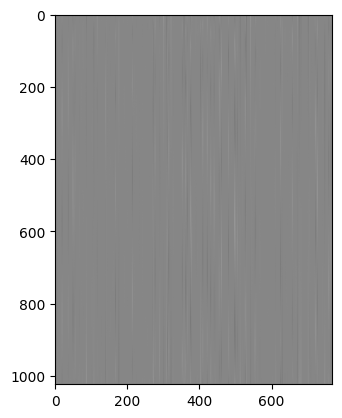

In [ ]:


plt.imshow(sd_hf['transformer.wpe.weight'], cmap='gray')

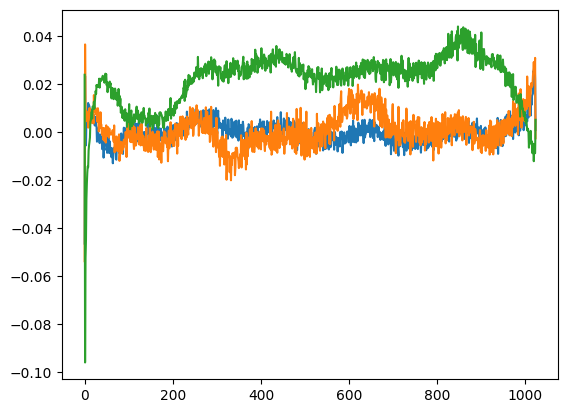

In [ ]:
plt.plot(sd_hf['transformer.wpe.weight'][:, 150]) # values of column 150, or n_emdb - 150
plt.plot(sd_hf['transformer.wpe.weight'][:, 200])
plt.plot(sd_hf['transformer.wpe.weight'][:, 250])

In [ ]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator('Hello, I am a language model,', max_length=30, num_return_sequences=5)

Device set to use mps:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Hello, I am a language model, and my project will be a language model for a language model. Please, please, please feel free to contribute your languages in the project.\n\nLet\'s start with the basic idea of the language model.\n\nThe language model is a model of the language. In a very simple language, for example, with the command "a" you can tell the compiler that a program is defined as a string. The compiler can find the definition of the program in the text file, and the list of strings to be matched against will be stored as a sequence of characters in the text file.\n\nSo, in a given language, you can define a program\'s function arguments, and its message can be found in its program. This is how the language model of a language is built.\n\nThe language model is a language model of the program. In a language, you can define a function as a string, and the compiler can find the definition of the program in the text file, and the list of strings to be match

---

# **This section is to wrap my head around tensor dims and ops**

In [7]:
z = torch.tensor([5, 7, 3], dtype=torch.long)
z, z.shape

(tensor([5, 7, 3]), torch.Size([3]))

In [8]:
z = (torch.tensor([5, 7, 3], dtype=torch.long))[None, ...]
z, z.shape

(tensor([[5, 7, 3]]), torch.Size([1, 3]))

In [12]:
z = torch.tensor([5, 7, 3], dtype=torch.long)
z = z.unsqueeze(dim=0)
z, z.shape

(tensor([[5, 7, 3]]), torch.Size([1, 3]))

In [7]:
x = torch.randn((3, 5, 7))
x, x.shape

(tensor([[[ 0.1704,  2.0897,  0.8554, -0.4726, -2.2125,  0.3940, -0.0347],
          [-0.6741, -1.2924, -0.6908, -1.1339, -0.7214,  0.1147,  0.8010],
          [ 1.1073, -0.1273,  0.5902, -1.0829,  1.3781, -0.2375,  0.5573],
          [ 0.0757,  0.1051, -0.2530, -1.0064,  1.5028, -0.2164, -1.1064],
          [-0.5293,  0.3522,  0.4981, -0.5200, -0.4881,  1.0730, -0.4999]],
 
         [[ 0.6148, -0.8116, -0.4384,  0.4092,  0.5547, -1.4349, -0.8659],
          [ 2.8443,  1.1178, -1.2053, -1.1100, -0.7541,  0.2766, -1.2616],
          [ 0.3765,  0.4558, -1.9596, -1.5605,  0.8494, -0.9420, -0.9867],
          [ 1.0942,  0.9435, -0.9947, -0.8101, -1.3435,  0.9831,  1.1500],
          [-0.6340, -0.0557, -0.5614, -1.2991, -0.1019,  0.0636,  0.5067]],
 
         [[ 1.5428, -0.2026, -1.4656, -1.4015,  1.0338, -0.4802,  0.2126],
          [-0.5486, -0.4908,  0.4039,  1.0698, -0.1851,  2.3348,  0.7309],
          [ 1.8392,  0.4673, -0.7400,  0.4556,  0.4307, -0.0477,  0.5881],
          [-0.0219,

In [13]:
x[:, [-1], :], x[:, [-1], :].shape

(tensor([[[-0.5293,  0.3522,  0.4981, -0.5200, -0.4881,  1.0730, -0.4999]],
 
         [[-0.6340, -0.0557, -0.5614, -1.2991, -0.1019,  0.0636,  0.5067]],
 
         [[ 1.2419,  1.5728,  0.6325,  0.1678,  0.1994,  2.1209,  1.3071]]]),
 torch.Size([3, 1, 7]))

In [37]:
x = nn.Linear(5, 20, bias=True)
o = x(torch.randn(1, 5))
o

tensor([[-0.2920,  0.6231, -0.5196, -0.8670,  1.0057, -0.1255,  0.7729,  0.1156,
          0.1541,  0.0897, -0.0414, -1.2642,  1.0933, -1.7643,  0.2113, -0.2178,
          1.1076,  0.1512, -0.1348,  0.0147]], grad_fn=<AddmmBackward0>)

In [38]:
x.weight, x.weight.shape

(Parameter containing:
 tensor([[-0.1902, -0.0774,  0.3595, -0.1730,  0.2957],
         [-0.0130, -0.2560,  0.4310, -0.1915,  0.1382],
         [-0.3407, -0.1999,  0.0725, -0.1001, -0.2070],
         [-0.1911,  0.4042, -0.1220, -0.2280,  0.1678],
         [ 0.4275,  0.4021,  0.2485,  0.0388, -0.3546],
         [-0.3691, -0.1926,  0.1720, -0.1849,  0.2864],
         [ 0.4296, -0.4283, -0.2635,  0.1447,  0.3942],
         [-0.0950, -0.2738,  0.2776, -0.0029, -0.3145],
         [-0.2016, -0.2355,  0.2593, -0.2657, -0.2962],
         [-0.3711, -0.4220,  0.2551, -0.2551,  0.3339],
         [ 0.0838,  0.0626, -0.4210,  0.0865, -0.4134],
         [-0.0139,  0.3351, -0.0959,  0.2392,  0.2644],
         [ 0.4405, -0.1656, -0.1644,  0.0959, -0.3935],
         [-0.2696,  0.0707, -0.1093,  0.3965, -0.0769],
         [ 0.1784,  0.0340,  0.2158,  0.0551,  0.3573],
         [-0.1204, -0.2828, -0.1984,  0.0388,  0.0623],
         [ 0.4446, -0.3006,  0.1906, -0.0022,  0.3566],
         [ 0.0779,  0.362

In [39]:
x.bias, x.bias.shape

(Parameter containing:
 tensor([-0.2805, -0.1033, -0.2137, -0.2589,  0.1765,  0.2705, -0.1156, -0.2258,
         -0.3278,  0.1155,  0.0183, -0.3186, -0.0353, -0.3508, -0.0439, -0.0170,
         -0.1999, -0.3392, -0.2794,  0.1421], requires_grad=True),
 torch.Size([20]))

In [43]:
test = torch.randn(3, 4, 5)
test

tensor([[[ 0.4705, -0.1394, -1.3037, -0.3220,  0.2544],
         [ 0.3800, -0.4584,  0.6986, -0.3670, -1.5771],
         [-0.2211, -1.5778,  1.3572,  1.4407, -0.0317],
         [-0.9059,  0.9852,  0.0801,  1.3139,  1.9259]],

        [[ 1.2356, -0.1954,  0.8302, -0.1872,  0.3379],
         [ 0.4846, -0.5264,  3.0443,  0.0615,  0.5706],
         [ 0.7729, -2.1178,  0.3872, -0.8128,  0.3658],
         [ 2.0425,  0.3925,  0.5401,  0.0397,  0.4123]],

        [[ 1.1263, -0.5541, -0.7765, -0.4450,  1.7849],
         [ 0.7888,  0.5541,  1.2321,  1.0150, -1.0959],
         [ 1.6791,  1.0112, -0.9476,  1.8102,  0.1024],
         [ 0.2087, -1.6496,  0.1924,  1.7198,  0.9107]]])

In [44]:
test[:, -2:]

tensor([[[-0.2211, -1.5778,  1.3572,  1.4407, -0.0317],
         [-0.9059,  0.9852,  0.0801,  1.3139,  1.9259]],

        [[ 0.7729, -2.1178,  0.3872, -0.8128,  0.3658],
         [ 2.0425,  0.3925,  0.5401,  0.0397,  0.4123]],

        [[ 1.6791,  1.0112, -0.9476,  1.8102,  0.1024],
         [ 0.2087, -1.6496,  0.1924,  1.7198,  0.9107]]])

In [8]:

config = { "block_size":  5, "n_embd": 8}


In [9]:

print(torch.tril(torch.ones(config["block_size"], config["block_size"])))
print(torch.tril(torch.ones(config["block_size"], config["block_size"])).shape)
print(torch.tril(torch.ones(config["block_size"], config["block_size"])).view(1, 1, config["block_size"], config["block_size"]))
print(torch.tril(torch.ones(config["block_size"], config["block_size"])).view(1, 1, config["block_size"], config["block_size"]).shape)

tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])
torch.Size([5, 5])
tensor([[[[1., 0., 0., 0., 0.],
          [1., 1., 0., 0., 0.],
          [1., 1., 1., 0., 0.],
          [1., 1., 1., 1., 0.],
          [1., 1., 1., 1., 1.]]]])
torch.Size([1, 1, 5, 5])


In [10]:
@dataclass
class GPTConfig:
  block_size: int = 256
  vocab_size: int = 65
  n_layer: int = 6
  n_head: int = 6
  n_embd: int = 384

In [11]:
c_attn = nn.Linear(GPTConfig.n_embd, 3 * GPTConfig.n_embd)

In [12]:
x = torch.randn(4, 12, GPTConfig.n_embd)
x.shape

torch.Size([4, 12, 384])

In [13]:
qkv = c_attn(x)
print(qkv.shape)
q, k, v = qkv.split(GPTConfig.n_embd, dim=2)
print(q.shape, k.shape, v.shape)

torch.Size([4, 12, 1152])
torch.Size([4, 12, 384]) torch.Size([4, 12, 384]) torch.Size([4, 12, 384])


In [14]:
test = torch.randn(2, 3, 5)
print(test.shape, test.size())
test

torch.Size([2, 3, 5]) torch.Size([2, 3, 5])


tensor([[[ 0.4971,  0.7686, -0.4821, -0.3700, -1.8971],
         [-0.3677, -0.7172, -2.2489,  1.1469,  0.1148],
         [ 1.0722,  2.1966,  1.1667,  0.8661, -1.4082]],

        [[ 0.4244, -0.8102, -0.3281,  0.4468, -0.2085],
         [ 0.4267,  0.4262, -0.7244,  0.4525,  1.2467],
         [-2.8815, -0.9146, -0.2705,  0.2437,  0.2414]]])

In [15]:
test.view(-1, 5)

tensor([[ 0.4971,  0.7686, -0.4821, -0.3700, -1.8971],
        [-0.3677, -0.7172, -2.2489,  1.1469,  0.1148],
        [ 1.0722,  2.1966,  1.1667,  0.8661, -1.4082],
        [ 0.4244, -0.8102, -0.3281,  0.4468, -0.2085],
        [ 0.4267,  0.4262, -0.7244,  0.4525,  1.2467],
        [-2.8815, -0.9146, -0.2705,  0.2437,  0.2414]])

In [16]:
print(test.transpose(1, 2).shape)
test.transpose(1, 2)

torch.Size([2, 5, 3])


tensor([[[ 0.4971, -0.3677,  1.0722],
         [ 0.7686, -0.7172,  2.1966],
         [-0.4821, -2.2489,  1.1667],
         [-0.3700,  1.1469,  0.8661],
         [-1.8971,  0.1148, -1.4082]],

        [[ 0.4244,  0.4267, -2.8815],
         [-0.8102,  0.4262, -0.9146],
         [-0.3281, -0.7244, -0.2705],
         [ 0.4468,  0.4525,  0.2437],
         [-0.2085,  1.2467,  0.2414]]])

In [17]:
print(test.transpose(-2, -1).shape)
test.transpose(-2, -1)

torch.Size([2, 5, 3])


tensor([[[ 0.4971, -0.3677,  1.0722],
         [ 0.7686, -0.7172,  2.1966],
         [-0.4821, -2.2489,  1.1667],
         [-0.3700,  1.1469,  0.8661],
         [-1.8971,  0.1148, -1.4082]],

        [[ 0.4244,  0.4267, -2.8815],
         [-0.8102,  0.4262, -0.9146],
         [-0.3281, -0.7244, -0.2705],
         [ 0.4468,  0.4525,  0.2437],
         [-0.2085,  1.2467,  0.2414]]])

In [18]:
emb = nn.Embedding(12, 12)
emb.weight

Parameter containing:
tensor([[ 0.1641,  0.9929, -3.5674,  0.7564, -2.5047, -1.0522,  1.7704,  0.3320,
          0.6937, -0.2092,  0.6158,  0.2528],
        [-0.0498,  1.1276,  0.8218, -1.7630,  1.1958,  0.6158,  0.1227,  0.2935,
          0.2396,  0.6117,  1.8944, -1.1162],
        [-0.3149, -0.2861, -0.7945,  1.9762,  0.7057,  0.1189,  0.8956,  0.6981,
          0.3824,  0.2397, -1.2174,  0.6982],
        [ 1.4088, -0.8785, -1.3487,  0.6502,  0.3958, -0.5200, -0.0068, -0.2865,
          0.6588, -0.9614, -0.5135,  1.0700],
        [-0.7186,  0.2951,  1.0987,  0.8830, -0.7344, -0.2718,  0.8379, -1.2183,
          1.0039, -0.8813,  0.2681, -0.8365],
        [-1.2235, -2.1764,  0.5906,  0.1028, -0.0252,  0.2547, -1.5834,  1.3719,
         -0.6860, -1.1147,  1.8850,  0.6261],
        [-0.2583, -1.6418,  0.2148,  0.8980,  0.3312,  0.6385, -0.4123, -1.7342,
         -0.8885, -0.4081,  1.4258, -1.3001],
        [ 0.7400,  1.9746, -0.6132, -0.3088, -0.2911, -1.9711,  0.9967, -0.9707,
        

In [19]:
idx = torch.arange(0, 5, dtype=torch.long)
idx

tensor([0, 1, 2, 3, 4])

In [20]:
emb(idx)

tensor([[ 0.1641,  0.9929, -3.5674,  0.7564, -2.5047, -1.0522,  1.7704,  0.3320,
          0.6937, -0.2092,  0.6158,  0.2528],
        [-0.0498,  1.1276,  0.8218, -1.7630,  1.1958,  0.6158,  0.1227,  0.2935,
          0.2396,  0.6117,  1.8944, -1.1162],
        [-0.3149, -0.2861, -0.7945,  1.9762,  0.7057,  0.1189,  0.8956,  0.6981,
          0.3824,  0.2397, -1.2174,  0.6982],
        [ 1.4088, -0.8785, -1.3487,  0.6502,  0.3958, -0.5200, -0.0068, -0.2865,
          0.6588, -0.9614, -0.5135,  1.0700],
        [-0.7186,  0.2951,  1.0987,  0.8830, -0.7344, -0.2718,  0.8379, -1.2183,
          1.0039, -0.8813,  0.2681, -0.8365]], grad_fn=<EmbeddingBackward0>)

In [21]:
tokens = torch.tensor([15496, 11, 314, 716, 257, 3303, 2746, 11], dtype=torch.long)
print(tokens)
tokens.shape

tensor([15496,    11,   314,   716,   257,  3303,  2746,    11])


torch.Size([8])

In [22]:
tokens = tokens.unsqueeze(0)
print(tokens)
tokens.shape

tensor([[15496,    11,   314,   716,   257,  3303,  2746,    11]])


torch.Size([1, 8])

In [23]:
tokens = tokens.repeat(5, 1)
print(tokens)
tokens.shape

tensor([[15496,    11,   314,   716,   257,  3303,  2746,    11],
        [15496,    11,   314,   716,   257,  3303,  2746,    11],
        [15496,    11,   314,   716,   257,  3303,  2746,    11],
        [15496,    11,   314,   716,   257,  3303,  2746,    11],
        [15496,    11,   314,   716,   257,  3303,  2746,    11]])


torch.Size([5, 8])

In [24]:
# from datasets import load_dataset

# ds = load_dataset("mwritescode/slither-audited-smart-contracts", "all-multilabel")

In [25]:
# import regex as re

# def format_source_code(sc):
#   formatted = re.sub(r'/\*[\s\S]*?\*/', '', sc)
#   formatted = re.sub(r'//[^\n]*', '', formatted)
#   formatted = re.sub(r'[\n\r]+', '\n', formatted)
#   return formatted

In [26]:
# formatted_sc = map(format_source_code, ds['train']['source_code'])

In [27]:
# formatted_sc = list(formatted_sc)
# formatted_sc[:5]

In [28]:
# formatted = '<|endoftext|> \n'.join(formatted_sc)

---

# **2. Let’s train: data batches (B,T) → logits (B,T,C)**

In [17]:
with open('../data/input.txt', 'r') as f:
  text = f.read()

data = text[:1000]
print(data[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [18]:

enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:25])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13, 198]


Let's revisit the forward function in our model:

  ``` python
    def forward(self, idx, targets=None):
    # idx is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, f'Cannot forward sequence of length {T}, block size is only {self.config.block_size}'

    # forward the token and positional embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
    pos_emb = self.transformer.wpe(pos) # shape (T, n_embd)
    tok_emb = self.transformer.wte(idx) # shape (B, T, n_embd)
    x = tok_emb + pos_emb # shape (B, T, n_embd)
    # forward to the block of the transformer
    for block in self.transformer.h:
       x = block(x)

    # forward to the final layer norm and classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
  
    return logits, loss
  ```

  
We have to convert these tokens into the shape(B, T) and T cannot be greater than block size

In [19]:
buf = torch.tensor(tokens[:24])
x = buf.view(4, 6)
print(x)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])


Now we also need to prepare the targets(default set to None) to calculate loss, so along with x we also need to prepare the label y

In [21]:
buf = torch.tensor(tokens[:24 + 1])
x = buf[: -1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


Now we have inputs and target

---

# **Wooh!!! Bug!! My Bad!! Let's revisit GPT2 tensors and "Attention is all you need paper"**

From the paper - section 3.4 Embeddings and Softmax:

We also use the usual learned linear transformation and softmax function to convert the decoder output to predicted next-token probabilities. 
**In our model, we share the same weight matrix between the two embedding layers and the pre-softmax linear transformation.**

Also the argument is given in this paper.
<a href="./papers/Using output embeddings to Improve LM.pdf">Using output embeddings to Improve Language papers</a>

This is the paragraph from the paper:

We call U the input embedding, and V the output embedding. In both matrices, we expect rows that correspond to similar words to be similar: for the input embedding, we would like the network to react similarly to synonyms, while in the output embedding, we would like the scores of words that are interchangeable to be similar

In [22]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

torch.Size([50257, 768])
torch.Size([50257, 768])


In [23]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [24]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

13172125651
13172125651


So essentially they are using the same tensor and they are point to same memory. We have to fix this in our implementation

---

# **Residual Init**

From GPT2 paper - section 2.3:

A modified initialization which accounts for the accumulation on the residual path with model depth is used. We scale the weights of residual layers at initialization by a factor of 1/√N where N is the number of residual layers.

In [36]:
# standard deviation grows inside the residual stream
x = torch.zeros(768)
n = 100 # example: 100 layers

for i in range(n):
  x += torch.randn(768) # 0 mean, 1 std

print(x.std())

tensor(9.8141)


So, we notice that for 100(N) layers the std has increased by 10(√N).

In [37]:
x = torch.zeros(768)
n = 100 # example: 100 layers

for i in range(n):
  x += n ** -0.5 * torch.randn(768) # 0 mean, 1 std

print(x.std())

tensor(0.9892)


# **Decay learning rate according to GPT-3**

In [38]:
import math
max_lr = 6e-4
min_lr = 0.1 * max_lr
warmup_steps = 10
max_steps = 50

def get_lr(it):

  # 1) Linear warm up for warmup_iterations
  if it < warmup_steps:
    print(f'Here 1: {max_lr * (it + 1) / warmup_steps}')
    return max_lr * (it + 1) / warmup_steps
  
  # 2) if it > lr_decay_iters return min learning rate
  if it > max_steps:
    print(f'Here 2: {min_lr}')
    return min_lr

  # 3) in between use cosine decay down to min learning rate
  decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
  print(f'{decay_ratio=}')
  assert 0 <= decay_ratio <= 1
  coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
  print(f'{coeff=}')
  print(f'final return: {min_lr + coeff * (max_lr - min_lr)}')
  return min_lr + coeff * (max_lr - min_lr)

In [39]:
get_lr(25)

decay_ratio=0.375
coeff=0.6913417161825449
final return: 0.00043332452673857416


0.00043332452673857416

In [40]:
max_lr * (10) / warmup_steps

0.0006

# **Gradient Accumulation**

In [41]:
import torch

net = torch.nn.Sequential(
  torch.nn.Linear(16, 32),
  torch.nn.GELU(),
  torch.nn.Linear(32, 1)
)

torch.random.manual_seed(42)
x = torch.randn(4, 16) # 4 examples
y = torch.randn(4, 1) # 4 examples
net.zero_grad()

yhat = net(x)
loss = torch.nn.functional.mse_loss(yhat, y)

loss.backward()
print(net[0].weight.grad.view(-1)[:10])

# the loss objective here is (due to reduction = mean)
# L = 1/4 * [
#               (y[0] - yhat[0]) ** 2 +
#               (y[1] - yhat[1]) ** 2 +
#               (y[2] - yhat[2]) ** 2 +
#               (y[3] - yhat[3]) ** 2 
# ]
# NOTE: 1/4

tensor([ 0.0617,  0.0043, -0.0131,  0.0017, -0.0190,  0.0232,  0.0283,  0.0538,
         0.0495,  0.0390])


In [42]:
# now let's do it with the grad_accum_steps of 4, and B = 1
# the loss objective here is different because
# accumulation in gradient <-----> SUM in loss

# L0 = (y[0] - yhat[0]) ** 2
# L1 = (y[1] - yhat[1]) ** 2
# L2 = (y[2] - yhat[2]) ** 2
# L3 = (y[3] - yhat[3]) ** 2

# L = L0 + L1 + L2 + L3
# NOTE: the normalizer of 1/4 is lost

net.zero_grad()
for i in range(4):
  yhat = net(x[i])
  loss = torch.nn.functional.mse_loss(yhat, y[i])
  loss.backward()
print(net[0].weight.grad.view(-1)[:10])

tensor([ 0.2468,  0.0172, -0.0525,  0.0068, -0.0760,  0.0930,  0.1131,  0.2150,
         0.1982,  0.1560])


We see that loss is not matching, to match we have to divide indv losses by 4

In [43]:
# now let's do it with the grad_accum_steps of 4, and B = 1
# the loss objective here is different because
# accumulation in gradient <-----> SUM in loss

# L0 = 1/4(y[0] - yhat[0]) ** 2
# L1 = 1/4(y[1] - yhat[1]) ** 2
# L2 = 1/4(y[2] - yhat[2]) ** 2
# L3 = 1/4(y[3] - yhat[3]) ** 2

# L = 1/4(L0 + L1 + L2 + L3)
# NOTE: the normalizer of 1/4 is lost

net.zero_grad()
for i in range(4):
  yhat = net(x[i])
  loss = torch.nn.functional.mse_loss(yhat, y[i])
  loss = loss / 4 # <-- normalizer
  loss.backward()
print(net[0].weight.grad.view(-1)[:10])

tensor([ 0.0617,  0.0043, -0.0131,  0.0017, -0.0190,  0.0232,  0.0283,  0.0538,
         0.0495,  0.0390])


Now it matches with the original implementation

# **Hella Swag**

In [44]:
import torch
torch.manual_seed(42)

tok_rows = [[32, 582, 318, 5586, 319, 257, 9753, 13, 339, 318, 1262, 14441, 284, 14441, 257, 5166, 286, 1341, 271, 13], [32, 582, 318, 5586, 319, 257, 9753, 13, 339, 318, 34759, 1241, 19867, 572, 13], [32, 582, 318, 5586, 319, 257, 9753, 13, 339, 318, 4769, 257, 6437, 1134, 338, 23441, 13], [32, 582, 318, 5586, 319, 257, 9753, 13, 339, 4940, 10427, 510, 9753, 278, 319, 257, 9753, 13]]
mask_rows = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

In [45]:
for tok_row, mask_row in zip(tok_rows, mask_rows):
  print(tok_row)
  print(mask_row)

[32, 582, 318, 5586, 319, 257, 9753, 13, 339, 318, 1262, 14441, 284, 14441, 257, 5166, 286, 1341, 271, 13]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[32, 582, 318, 5586, 319, 257, 9753, 13, 339, 318, 34759, 1241, 19867, 572, 13]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
[32, 582, 318, 5586, 319, 257, 9753, 13, 339, 318, 4769, 257, 6437, 1134, 338, 23441, 13]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]
[32, 582, 318, 5586, 319, 257, 9753, 13, 339, 4940, 10427, 510, 9753, 278, 319, 257, 9753, 13]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]


9 context token and rest are example tokenss

In [46]:
tokens = torch.zeros((4, 21), dtype=torch.long)
mask = torch.zeros((4, 21), dtype=torch.long)

for i, (tok_row, mask_row) in enumerate(zip(tok_rows, mask_rows)):
  tokens[i, :len(tok_row)] = torch.tensor(tok_row)
  mask[i, :len(mask_row)] = torch.tensor(mask_row)

tokens, tokens.shape, mask, mask.shape

(tensor([[   32,   582,   318,  5586,   319,   257,  9753,    13,   339,   318,
           1262, 14441,   284, 14441,   257,  5166,   286,  1341,   271,    13,
              0],
         [   32,   582,   318,  5586,   319,   257,  9753,    13,   339,   318,
          34759,  1241, 19867,   572,    13,     0,     0,     0,     0,     0,
              0],
         [   32,   582,   318,  5586,   319,   257,  9753,    13,   339,   318,
           4769,   257,  6437,  1134,   338, 23441,    13,     0,     0,     0,
              0],
         [   32,   582,   318,  5586,   319,   257,  9753,    13,   339,  4940,
          10427,   510,  9753,   278,   319,   257,  9753,    13,     0,     0,
              0]]),
 torch.Size([4, 21]),
 tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,

In [47]:
tokens[..., 1:].shape, tokens[..., 1:]

(torch.Size([4, 20]),
 tensor([[  582,   318,  5586,   319,   257,  9753,    13,   339,   318,  1262,
          14441,   284, 14441,   257,  5166,   286,  1341,   271,    13,     0],
         [  582,   318,  5586,   319,   257,  9753,    13,   339,   318, 34759,
           1241, 19867,   572,    13,     0,     0,     0,     0,     0,     0],
         [  582,   318,  5586,   319,   257,  9753,    13,   339,   318,  4769,
            257,  6437,  1134,   338, 23441,    13,     0,     0,     0,     0],
         [  582,   318,  5586,   319,   257,  9753,    13,   339,  4940, 10427,
            510,  9753,   278,   319,   257,  9753,    13,     0,     0,     0]]))

In [48]:
shift_tokens = (tokens[..., 1:]).contiguous()
shift_tokens, shift_tokens.shape

(tensor([[  582,   318,  5586,   319,   257,  9753,    13,   339,   318,  1262,
          14441,   284, 14441,   257,  5166,   286,  1341,   271,    13,     0],
         [  582,   318,  5586,   319,   257,  9753,    13,   339,   318, 34759,
           1241, 19867,   572,    13,     0,     0,     0,     0,     0,     0],
         [  582,   318,  5586,   319,   257,  9753,    13,   339,   318,  4769,
            257,  6437,  1134,   338, 23441,    13,     0,     0,     0,     0],
         [  582,   318,  5586,   319,   257,  9753,    13,   339,  4940, 10427,
            510,  9753,   278,   319,   257,  9753,    13,     0,     0,     0]]),
 torch.Size([4, 20]))

In [49]:
shift_tokens.view(-1), shift_tokens.view(-1).shape

(tensor([  582,   318,  5586,   319,   257,  9753,    13,   339,   318,  1262,
         14441,   284, 14441,   257,  5166,   286,  1341,   271,    13,     0,
           582,   318,  5586,   319,   257,  9753,    13,   339,   318, 34759,
          1241, 19867,   572,    13,     0,     0,     0,     0,     0,     0,
           582,   318,  5586,   319,   257,  9753,    13,   339,   318,  4769,
           257,  6437,  1134,   338, 23441,    13,     0,     0,     0,     0,
           582,   318,  5586,   319,   257,  9753,    13,   339,  4940, 10427,
           510,  9753,   278,   319,   257,  9753,    13,     0,     0,     0]),
 torch.Size([80]))

In [50]:
DATA_CACHE_DIR = os.path.join(os.getcwd(), 'hellaswag')
DATA_CACHE_DIR

'/Users/arpankumarnandi/Documents/workspace/Neural Networks - Zero to Hero/nanoGPT/hellaswag'

In [51]:
def download_file(url: str, fname: str, chunk_size=1024):
  '''Helper function to download a file from a given url'''
  resp = requests.get(url, stream=True)
  total = int(resp.headers.get('content-length', 0))

  with open(fname, 'wb') as file, tqdm(
    desc=fname,
    total=total,
    unit='iB',
    unit_scale=True, 
    unit_divisor=1024
  ) as bar:
    for data in resp.iter_content(chunk_size=chunk_size):
      size = file.write(data)
      bar.update(size)

In [52]:
hellaswags = {
    'train': 'https://raw.githubusercontent.com/rowanz/hellaswag/master/data/hellaswag_train.jsonl',
    'val': 'https://raw.githubusercontent.com/rowanz/hellaswag/master/data/hellaswag_val.jsonl',
    'test': 'https://raw.githubusercontent.com/rowanz/hellaswag/master/data/hellaswag_test.jsonl',
}

In [53]:
enc = tiktoken.get_encoding('gpt2')

In [54]:
def download(split):
   '''Downloads HellaSwag DATA_CACHE_DIR'''
   os.makedirs(DATA_CACHE_DIR, exist_ok=True)
   data_url = hellaswags[split]
   data_filename = os.path.join(DATA_CACHE_DIR, f'hellaswag_{split}.jsonl')
   
   if not os.path.exists(data_filename):
     print(f'Downloading {data_url} to {data_filename}')
     download_file(data_url, data_filename)

In [ ]:
def render_example(example):
    """
    Given the example as a dictionary, render it as three torch tensors:
    - tokens (the tokens of context + completion, of size 4xN, as there are always 4 candidates)
    - mask (is 1 in the region of the candidate completion, where we evaluate likelihoods)
    - label (the index of the correct completion, which we hope has the highest likelihood)
    """
    ctx = example["ctx"]
    label = example["label"]
    endings = example["endings"]

    # data needed to reproduce this eval on the C size
    data = {
        "label": label,
        "ctx_tokens": None,
        "ending_tokens": [],
    }

    # gather up all the tokens
    ctx_tokens = enc.encode(ctx)
    data["ctx_tokens"] = ctx_tokens
    tok_rows = []
    mask_rows = []
    for end in endings:
        end_tokens = enc.encode(" " + end) # note: prepending " " because GPT-2 tokenizer
        tok_rows.append(ctx_tokens + end_tokens)
        mask_rows.append([0]*len(ctx_tokens) + [1]*len(end_tokens))
        data["ending_tokens"].append(end_tokens)

    # have to be careful during the collation because the number of tokens in each row can differ
    max_len = max(len(row) for row in tok_rows)
    tokens = torch.zeros((4, max_len), dtype=torch.long)
    mask = torch.zeros((4, max_len), dtype=torch.long)
    for i, (tok_row, mask_row) in enumerate(zip(tok_rows, mask_rows)):
        tokens[i, :len(tok_row)] = torch.tensor(tok_row)
        mask[i, :len(mask_row)] = torch.tensor(mask_row)

    return data, tokens, mask, label

In [59]:
def iterate_examples(split):
  # there are 10,042 examples in total in val
  download(split)
  with open(os.path.join(DATA_CACHE_DIR, f"hellaswag_{split}.jsonl"), "r") as f:
    for line in f:
      example = json.loads(line)
      yield example

In [60]:
for example in iterate_examples('val'):
    print(f'{example=}')
    data, tokens, mask, label = render_example(example)
    print(f'{data=} | {tokens=} | {mask=} | {label=}')
    break;

example={'ind': 24, 'activity_label': 'Roof shingle removal', 'ctx_a': 'A man is sitting on a roof.', 'ctx_b': 'he', 'ctx': 'A man is sitting on a roof. he', 'split': 'val', 'split_type': 'indomain', 'label': 3, 'endings': ['is using wrap to wrap a pair of skis.', 'is ripping level tiles off.', "is holding a rubik's cube.", 'starts pulling up roofing on a roof.'], 'source_id': 'activitynet~v_-JhWjGDPHMY'}
data={'label': 3, 'ctx_tokens': [32, 582, 318, 5586, 319, 257, 9753, 13, 339], 'ending_tokens': [[318, 1262, 14441, 284, 14441, 257, 5166, 286, 1341, 271, 13], [318, 34759, 1241, 19867, 572, 13], [318, 4769, 257, 6437, 1134, 338, 23441, 13], [4940, 10427, 510, 9753, 278, 319, 257, 9753, 13]]} | tokens=tensor([[   32,   582,   318,  5586,   319,   257,  9753,    13,   339,   318,
          1262, 14441,   284, 14441,   257,  5166,   286,  1341,   271,    13],
        [   32,   582,   318,  5586,   319,   257,  9753,    13,   339,   318,
         34759,  1241, 19867,   572,    13,     0,

In [66]:
tokens, tokens.shape, mask, mask.shape

(tensor([[   32,   582,   318,  5586,   319,   257,  9753,    13,   339,   318,
           1262, 14441,   284, 14441,   257,  5166,   286,  1341,   271,    13],
         [   32,   582,   318,  5586,   319,   257,  9753,    13,   339,   318,
          34759,  1241, 19867,   572,    13,     0,     0,     0,     0,     0],
         [   32,   582,   318,  5586,   319,   257,  9753,    13,   339,   318,
           4769,   257,  6437,  1134,   338, 23441,    13,     0,     0,     0],
         [   32,   582,   318,  5586,   319,   257,  9753,    13,   339,  4940,
          10427,   510,  9753,   278,   319,   257,  9753,    13,     0,     0]]),
 torch.Size([4, 20]),
 tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]]),
 torch.Size([4, 20]))

In [65]:
logits = model_hf(tokens).logits
logits, logits.shape

(tensor([[[ -33.5705,  -32.7689,  -35.4509,  ...,  -40.9807,  -40.1866,
            -33.2152],
          [-105.0331, -103.2583, -110.3992,  ..., -111.8692, -104.8638,
           -105.6673],
          [-119.8806, -117.7583, -123.3105,  ..., -127.7225, -120.2321,
           -120.7401],
          ...,
          [ -98.9865,  -95.4444,  -97.4640,  ..., -108.0764, -107.3866,
           -100.0664],
          [-128.3072, -128.1641, -132.5630,  ..., -141.1547, -139.0249,
           -128.6488],
          [-108.6667, -107.1692, -107.7597,  ..., -113.0092, -113.0028,
           -103.4984]],
 
         [[ -33.5705,  -32.7689,  -35.4509,  ...,  -40.9807,  -40.1866,
            -33.2152],
          [-105.0331, -103.2583, -110.3992,  ..., -111.8692, -104.8638,
           -105.6673],
          [-119.8806, -117.7583, -123.3105,  ..., -127.7225, -120.2321,
           -120.7401],
          ...,
          [ -81.1260,  -85.5750,  -84.7267,  ...,  -95.5109,  -93.9703,
            -84.2437],
          [ -75.6

In [67]:
shift_logits = (logits[..., :-1, :]).contiguous()
shift_logits, shift_logits.shape


(tensor([[[ -33.5705,  -32.7689,  -35.4509,  ...,  -40.9807,  -40.1866,
            -33.2152],
          [-105.0331, -103.2583, -110.3992,  ..., -111.8692, -104.8638,
           -105.6673],
          [-119.8806, -117.7583, -123.3105,  ..., -127.7225, -120.2321,
           -120.7401],
          ...,
          [-106.3072, -104.3022, -108.6029,  ..., -107.9997, -109.4300,
           -106.2348],
          [ -98.9865,  -95.4444,  -97.4640,  ..., -108.0764, -107.3866,
           -100.0664],
          [-128.3072, -128.1641, -132.5630,  ..., -141.1547, -139.0249,
           -128.6488]],
 
         [[ -33.5705,  -32.7689,  -35.4509,  ...,  -40.9807,  -40.1866,
            -33.2152],
          [-105.0331, -103.2583, -110.3992,  ..., -111.8692, -104.8638,
           -105.6673],
          [-119.8806, -117.7583, -123.3105,  ..., -127.7225, -120.2321,
           -120.7401],
          ...,
          [ -87.2549,  -91.0028,  -89.7563,  ..., -101.0882,  -98.9782,
            -89.5715],
          [ -81.1

In [69]:
flat_shift_logits = shift_logits.view(-1, shift_logits.size(-1))
flat_shift_logits, flat_shift_logits.shape

(tensor([[ -33.5705,  -32.7689,  -35.4509,  ...,  -40.9807,  -40.1866,
           -33.2152],
         [-105.0331, -103.2583, -110.3992,  ..., -111.8692, -104.8638,
          -105.6673],
         [-119.8806, -117.7583, -123.3105,  ..., -127.7225, -120.2321,
          -120.7401],
         ...,
         [ -99.9257, -100.0989, -104.4342,  ..., -114.9653, -111.0959,
          -101.0190],
         [-107.3500, -106.5544, -107.0907,  ..., -113.0025, -111.9330,
          -102.7872],
         [-101.7971, -103.1369, -102.5732,  ..., -112.5466, -109.8922,
          -101.0920]], grad_fn=<ViewBackward0>),
 torch.Size([76, 50257]))

In [103]:
print(enc.decode(tokens[0].tolist()))
print(enc.decode(tokens[1].tolist()))
print(enc.decode(tokens[2].tolist()))
print(enc.decode(tokens[3].tolist()))

A man is sitting on a roof. he is using wrap to wrap a pair of skis.
A man is sitting on a roof. he is ripping level tiles off.!!!!!
A man is sitting on a roof. he is holding a rubik's cube.!!!
A man is sitting on a roof. he starts pulling up roofing on a roof.!!


In [104]:
shift_tokens = (tokens[..., 1:]).contiguous()
shift_tokens, shift_tokens.shape

(tensor([[  582,   318,  5586,   319,   257,  9753,    13,   339,   318,  1262,
          14441,   284, 14441,   257,  5166,   286,  1341,   271,    13],
         [  582,   318,  5586,   319,   257,  9753,    13,   339,   318, 34759,
           1241, 19867,   572,    13,     0,     0,     0,     0,     0],
         [  582,   318,  5586,   319,   257,  9753,    13,   339,   318,  4769,
            257,  6437,  1134,   338, 23441,    13,     0,     0,     0],
         [  582,   318,  5586,   319,   257,  9753,    13,   339,  4940, 10427,
            510,  9753,   278,   319,   257,  9753,    13,     0,     0]]),
 torch.Size([4, 19]))

In [105]:
print(enc.decode(shift_tokens[0].tolist()))
print(enc.decode(shift_tokens[1].tolist()))
print(enc.decode(shift_tokens[2].tolist()))
print(enc.decode(shift_tokens[3].tolist()))

 man is sitting on a roof. he is using wrap to wrap a pair of skis.
 man is sitting on a roof. he is ripping level tiles off.!!!!!
 man is sitting on a roof. he is holding a rubik's cube.!!!
 man is sitting on a roof. he starts pulling up roofing on a roof.!!


why???

In [70]:
flat_shift_tokens = shift_tokens.view(-1)
flat_shift_tokens, flat_shift_tokens.shape

(tensor([  582,   318,  5586,   319,   257,  9753,    13,   339,   318,  1262,
         14441,   284, 14441,   257,  5166,   286,  1341,   271,    13,   582,
           318,  5586,   319,   257,  9753,    13,   339,   318, 34759,  1241,
         19867,   572,    13,     0,     0,     0,     0,     0,   582,   318,
          5586,   319,   257,  9753,    13,   339,   318,  4769,   257,  6437,
          1134,   338, 23441,    13,     0,     0,     0,   582,   318,  5586,
           319,   257,  9753,    13,   339,  4940, 10427,   510,  9753,   278,
           319,   257,  9753,    13,     0,     0]),
 torch.Size([76]))

In [71]:
shift_losses = F.cross_entropy(flat_shift_logits, flat_shift_tokens, reduction='none')
shift_losses, shift_losses.shape

(tensor([7.3022e+00, 3.3172e+00, 6.1764e+00, 1.3953e+00, 8.9699e-01, 5.5496e+00,
         3.7710e+00, 7.8737e+00, 1.5086e+00, 5.8585e+00, 1.1923e+01, 2.1637e+00,
         2.7706e+00, 2.6047e+00, 5.8060e+00, 1.1081e-02, 7.5942e+00, 1.6238e+00,
         1.5568e+00, 7.3022e+00, 3.3172e+00, 6.1764e+00, 1.3953e+00, 8.9699e-01,
         5.5496e+00, 3.7710e+00, 7.8737e+00, 1.5086e+00, 9.2569e+00, 1.4073e+01,
         4.3877e+00, 1.3536e+00, 4.0586e+00, 1.0673e+01, 6.7367e+00, 3.7361e+00,
         3.0185e+00, 2.4372e+00, 7.3022e+00, 3.3172e+00, 6.1764e+00, 1.3953e+00,
         8.9699e-01, 5.5496e+00, 3.7710e+00, 7.8737e+00, 1.5086e+00, 3.0816e+00,
         8.8093e-01, 1.1994e+01, 3.4135e+00, 6.1871e-01, 5.1057e-01, 1.5803e+00,
         1.1406e+01, 7.1156e+00, 4.3184e+00, 7.3022e+00, 3.3172e+00, 6.1764e+00,
         1.3953e+00, 8.9699e-01, 5.5496e+00, 3.7710e+00, 7.8737e+00, 5.0368e+00,
         4.9301e+00, 3.0012e+00, 9.0537e+00, 4.1260e+00, 3.9609e+00, 2.1955e+00,
         2.9105e+00, 1.4165e

In [72]:
shift_losses = shift_losses.view(tokens.size(0), -1)
shift_losses, shift_losses.shape

(tensor([[7.3022e+00, 3.3172e+00, 6.1764e+00, 1.3953e+00, 8.9699e-01, 5.5496e+00,
          3.7710e+00, 7.8737e+00, 1.5086e+00, 5.8585e+00, 1.1923e+01, 2.1637e+00,
          2.7706e+00, 2.6047e+00, 5.8060e+00, 1.1081e-02, 7.5942e+00, 1.6238e+00,
          1.5568e+00],
         [7.3022e+00, 3.3172e+00, 6.1764e+00, 1.3953e+00, 8.9699e-01, 5.5496e+00,
          3.7710e+00, 7.8737e+00, 1.5086e+00, 9.2569e+00, 1.4073e+01, 4.3877e+00,
          1.3536e+00, 4.0586e+00, 1.0673e+01, 6.7367e+00, 3.7361e+00, 3.0185e+00,
          2.4372e+00],
         [7.3022e+00, 3.3172e+00, 6.1764e+00, 1.3953e+00, 8.9699e-01, 5.5496e+00,
          3.7710e+00, 7.8737e+00, 1.5086e+00, 3.0816e+00, 8.8093e-01, 1.1994e+01,
          3.4135e+00, 6.1871e-01, 5.1057e-01, 1.5803e+00, 1.1406e+01, 7.1156e+00,
          4.3184e+00],
         [7.3022e+00, 3.3172e+00, 6.1764e+00, 1.3953e+00, 8.9699e-01, 5.5496e+00,
          3.7710e+00, 7.8737e+00, 5.0368e+00, 4.9301e+00, 3.0012e+00, 9.0537e+00,
          4.1260e+00, 3.9609e

In [75]:
mask, mask.shape

(tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]]),
 torch.Size([4, 20]))

In [76]:
shift_mask = (mask[..., 1:]).contiguous()
shift_mask, shift_mask.shape

(tensor([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]]),
 torch.Size([4, 19]))

In [77]:
masked_shift_losses = shift_losses * shift_mask
masked_shift_losses, masked_shift_losses.shape

(tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 1.5086e+00, 5.8585e+00, 1.1923e+01, 2.1637e+00,
          2.7706e+00, 2.6047e+00, 5.8060e+00, 1.1081e-02, 7.5942e+00, 1.6238e+00,
          1.5568e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 1.5086e+00, 9.2569e+00, 1.4073e+01, 4.3877e+00,
          1.3536e+00, 4.0586e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 1.5086e+00, 3.0816e+00, 8.8093e-01, 1.1994e+01,
          3.4135e+00, 6.1871e-01, 5.1057e-01, 1.5803e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 5.0368e+00, 4.9301e+00, 3.0012e+00, 9.0537e+00,
          4.1260e+00, 3.9609e

In [78]:
sum_loss = masked_shift_losses.sum(dim=1)
sum_loss

tensor([43.4215, 34.6390, 23.5884, 36.6311], grad_fn=<SumBackward1>)

In [79]:
avg_loss = sum_loss / shift_mask.sum(dim=1)
avg_loss, avg_loss.shape

(tensor([3.9474, 5.7732, 2.9485, 4.0701], grad_fn=<DivBackward0>),
 torch.Size([4]))

In [81]:
pred = sum_loss.argmin().item()
pred_norm = avg_loss.argmin().item()
pred, pred_norm

(2, 2)

In [86]:
int(pred == label)

0